In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)


In [ ]:
DATA_DIR = Path('../../data/lab03/sun_calibration')

# Default plot frequency window [GHz] — applied to all spectral/waterfall axes
PLOT_BAND_GHZ = (9.9, 10.0)

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} captures from {DATA_DIR.resolve()}')

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT

# Sky-frequency axis for all 1024 channels (SNAP 2048-pt real FFT)
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

# ---------------------------------------------------------------------------
# Detect artifact channels: compare each channel to its nearest neighbours.
# A single-channel spike at k satisfies mean_amp[k] >> mean of k±1..k±3.
# This is robust even when broad sky emission elevates the local background.
# ---------------------------------------------------------------------------
raw_amp  = np.array([np.abs(f['corr']) for f in files])  # (N, N_CH)
mean_amp = raw_amp.mean(axis=0)                          # (N_CH,)

# neighbour mean: 3 channels on each side, skipping the channel itself
HALF     = 3
SPIKE_THR = 4.0
bad = []
for k in range(N_CH):
    lo = max(0, k - HALF)
    hi = min(N_CH, k + HALF + 1)
    neighbours = np.concatenate([mean_amp[lo:k], mean_amp[k+1:hi]])
    if len(neighbours) and mean_amp[k] > SPIKE_THR * neighbours.mean():
        bad.append(k)
BAD_CHANNELS = bad

print(f'Artifact channels detected: {BAD_CHANNELS}')
print(f'  ({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# Global peak amplitude (excluding artifacts) — used to normalise all spectra
all_amp                  = raw_amp.copy()
all_amp[:, BAD_CHANNELS] = 0.0
AMP_PEAK                 = all_amp.max()

print(f'Band       : {F_SKY_GHZ[1]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  '
      f'({DF_HZ/1e3:.1f} kHz/ch, {N_CH} ch)')
print(f'Global peak: {AMP_PEAK:.4f}  (used for normalisation)')

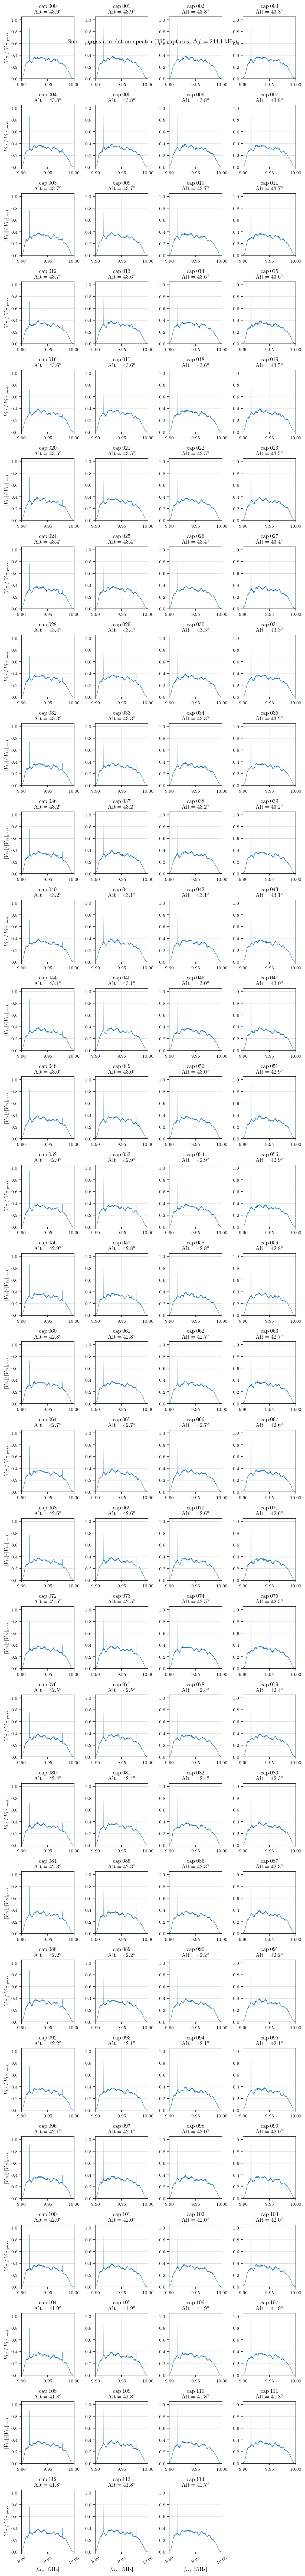

In [3]:
n     = len(files)
NCOLS = 4
nrows = int(np.ceil(n / NCOLS))

fig, axes = plt.subplots(
    nrows, NCOLS,
    figsize=(TEXTWIDTH_IN, 2.2 * nrows),
)
axes_flat = np.array(axes).flatten()

for i, f in enumerate(files):
    ax  = axes_flat[i]
    amp = np.abs(f['corr']).astype(float) / AMP_PEAK   # dimensionless in [0, 1]
    amp[0] = np.nan                                     # mask DC / LO

    ax.plot(F_SKY_GHZ, amp, lw=LW_FINE, color=PRIMARY_COLOR)

    ax.set_title(
        rf'\textrm{{cap\,{i:03d}}}' + '\n' +
        rf'$\mathrm{{Alt}}={float(f["alt_deg"]):.1f}^{{\circ}}$',
    )

    if i % NCOLS == 0:
        ax.set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
    if i >= (nrows - 1) * NCOLS:
        ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
        ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y')
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_ylim(0, 1.05)

# Hide unused axes
for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle(
    rf'Sun --- cross-correlation spectra '
    rf'({n}\,captures, $\Delta f={DF_HZ/1e3:.1f}$\,kHz)',
)
fig.tight_layout()
plt.show()


In [4]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    t = Time(unix_t, format='unix')
    sun = get_sun(t)
    return sun.ra.deg

# Sort files by mid-capture unix time
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j]  for j in order]
paths_s   = [paths[j]  for j in order]
t_rel     = unix_sort - unix_sort[0]          # seconds since first capture

# Per-capture Sun RA and HA
# Sun moves ~1°/day → must recompute RA at each capture's midpoint
lst_arr    = np.array([_lst_deg(t) for t in unix_sort])
sun_ra_arr = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg     = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# Peak channel across all captures (excluding DC)
k_peak     = int(np.argmax(all_amp.mean(axis=0)))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Sun RA range : {sun_ra_arr.min():.4f}° – {sun_ra_arr.max():.4f}°  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f}°)')
print(f'HA range     : {ha_deg.min():.2f}° → {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')


Sun RA range : 357.2021° – 357.2126°  (span 0.0105°)
HA range     : 27.19° → 31.34°  (4.15° span)
Peak channel : k=512,  f_sky=9.9150 GHz
Amp  (norm)  : mean=0.800,  std=0.070
Phase        : mean=-106.9°,  std=130.3°


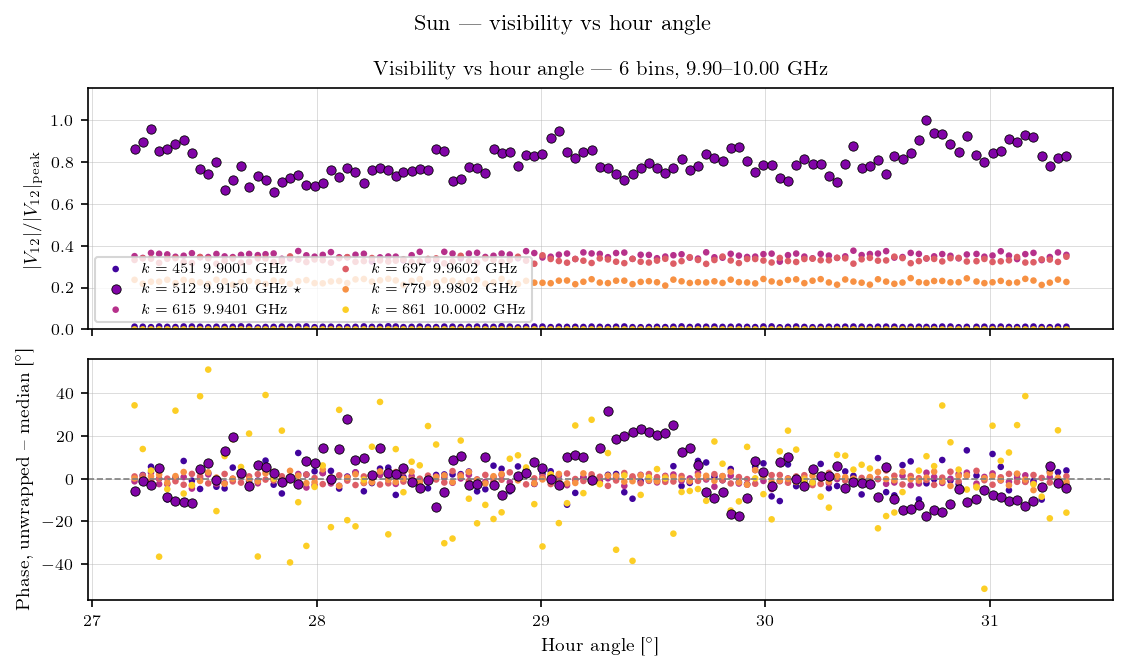

In [5]:
# ---------------------------------------------------------------------------
# Amplitude vs HA  +  unwrapped phase (median-subtracted) vs HA
# — overplotted for N_BINS frequency bins across the observation band —
# ---------------------------------------------------------------------------

N_BINS = 6   # number of frequency bins to overplot

# Select bin channels evenly spaced across PLOT_BAND_GHZ, skipping bad channels
f_lo, f_hi = PLOT_BAND_GHZ
ch_lo = int(np.searchsorted(F_SKY_GHZ, f_lo))
ch_hi = int(np.searchsorted(F_SKY_GHZ, f_hi))
candidates = np.round(np.linspace(ch_lo, ch_hi, N_BINS)).astype(int)
bin_channels = np.array([
    ch if ch not in BAD_CHANNELS else ch + 1
    for ch in candidates
])

# Replace the bin closest to k_peak with k_peak itself so it's always shown
bin_channels[np.argmin(np.abs(bin_channels - k_peak))] = k_peak

colors = plt.colormaps['plasma'](np.linspace(0.1, 0.9, N_BINS))

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True)

for color, ch in zip(colors, bin_channels):
    vis    = np.array([f['corr'][ch] for f in files_s])
    amp    = np.abs(vis) / AMP_PEAK
    phi_uw = np.rad2deg(np.unwrap(np.angle(vis)))
    phi_uw -= np.median(phi_uw)

    is_peak = (ch == k_peak)
    label   = rf'$k={ch}$  {F_SKY_GHZ[ch]:.4f} GHz' + (r' $\star$' if is_peak else '')
    kw = dict(s=SCATTER_S_FINE * (2 if is_peak else 1),
              color=color, label=label,
              edgecolors='k' if is_peak else 'none',
              linewidths=0.4, zorder=3 if is_peak else 2)

    axes[0].scatter(ha_deg, amp,    **kw)
    axes[1].scatter(ha_deg, phi_uw, **kw)

axes[0].set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
axes[0].set_ylim(0, 1.15)
axes[0].set_title(
    rf'Visibility vs hour angle --- {N_BINS} bins, '
    rf'{f_lo:.2f}--{f_hi:.2f} GHz'
)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2, loc='lower left')

axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--')
axes[1].set_ylabel(r'Phase, unwrapped -- median [$^\circ$]')
axes[1].set_xlabel(r'Hour angle [$^\circ$]')

fig.suptitle(r'Sun --- visibility vs hour angle')
fig.tight_layout()
plt.show()

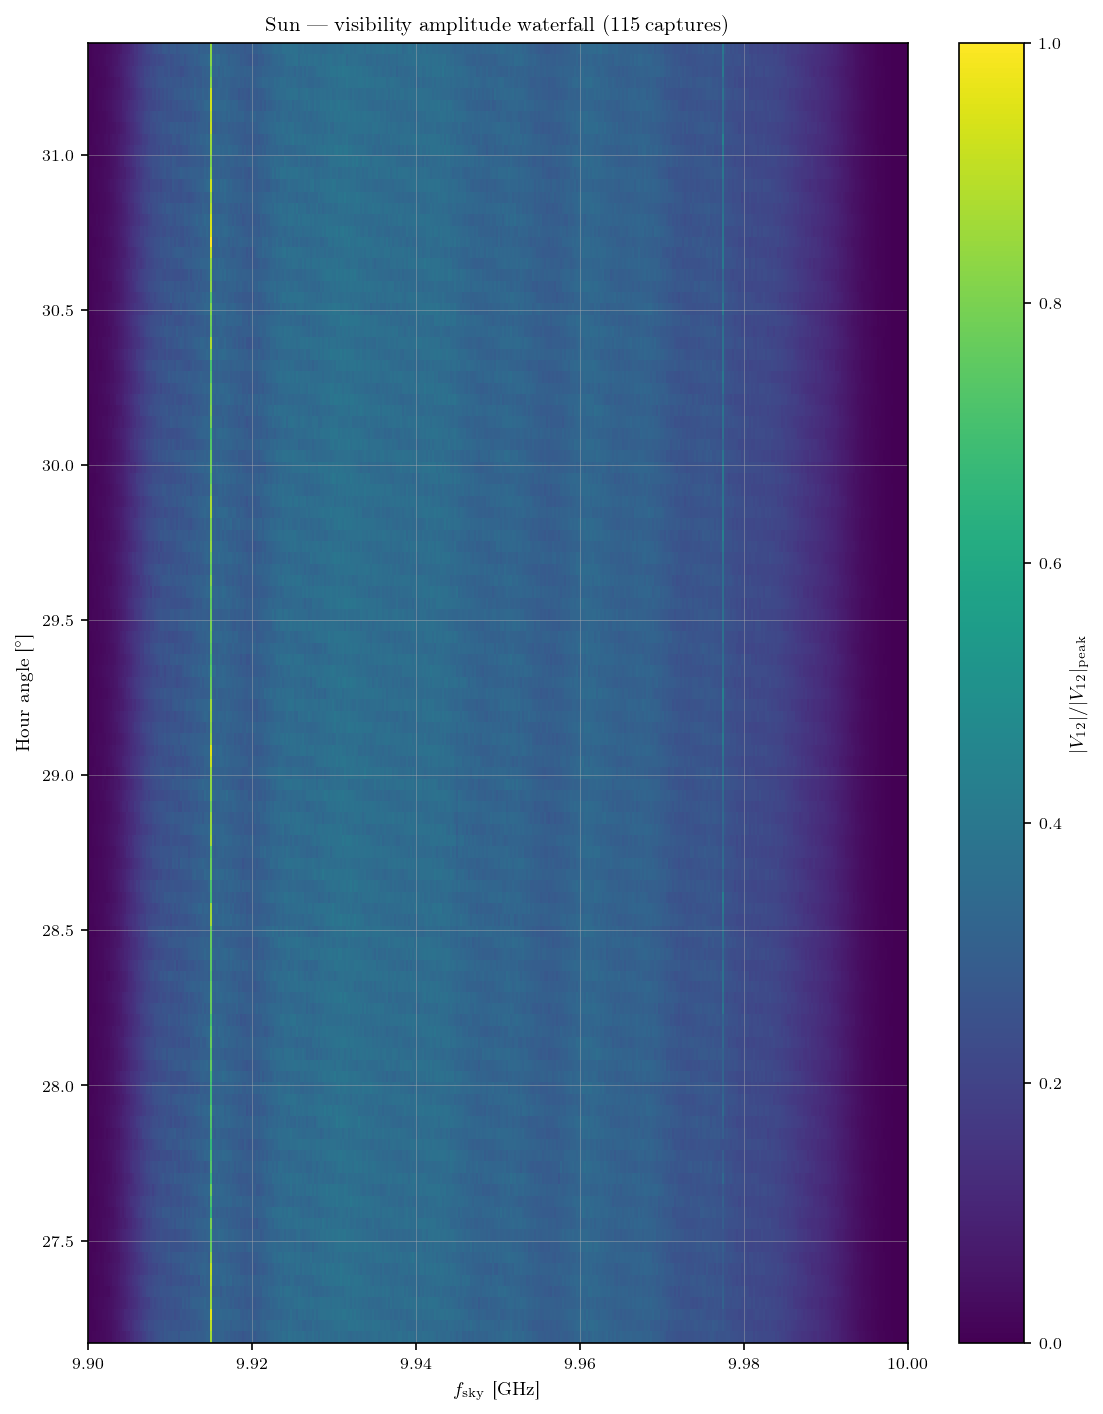

In [6]:
# ---------------------------------------------------------------------------
# Waterfall (spectrogram): amplitude vs frequency × hour angle
# Rows = captures sorted by time; columns = sky-frequency channels
# ---------------------------------------------------------------------------

amp_matrix = np.array([np.abs(f['corr']) / AMP_PEAK for f in files_s])
amp_matrix[:, BAD_CHANNELS] = np.nan   # mask FPGA artifacts

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 9.5))
im = ax.pcolormesh(
    F_SKY_GHZ,
    ha_deg,
    amp_matrix,
    vmin=0, vmax=1,
    cmap='viridis',
    shading='auto',
)
ax.set_xlim(*PLOT_BAND_GHZ)
ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
ax.set_ylabel(r'Hour angle [$^\circ$]')
ax.set_title(
    rf'Sun --- visibility amplitude waterfall '
    rf'({len(files_s)}\,captures)'
)
fig.colorbar(im, ax=ax, label=r'$|V_{12}| / |V_{12}|_{\rm peak}$')
fig.tight_layout()
plt.show()

Captures        : 115
Wall-clock span : 1002.5 s  (16.7 min)
On-sky total    : 680.4 s  (11.3 min)
Duty cycle      : 67.9%
n_acc per cap   : min=5  mean=6.0  max=6
Gap (s)         : min=2.69  median=2.79  mean=2.83  max=4.74


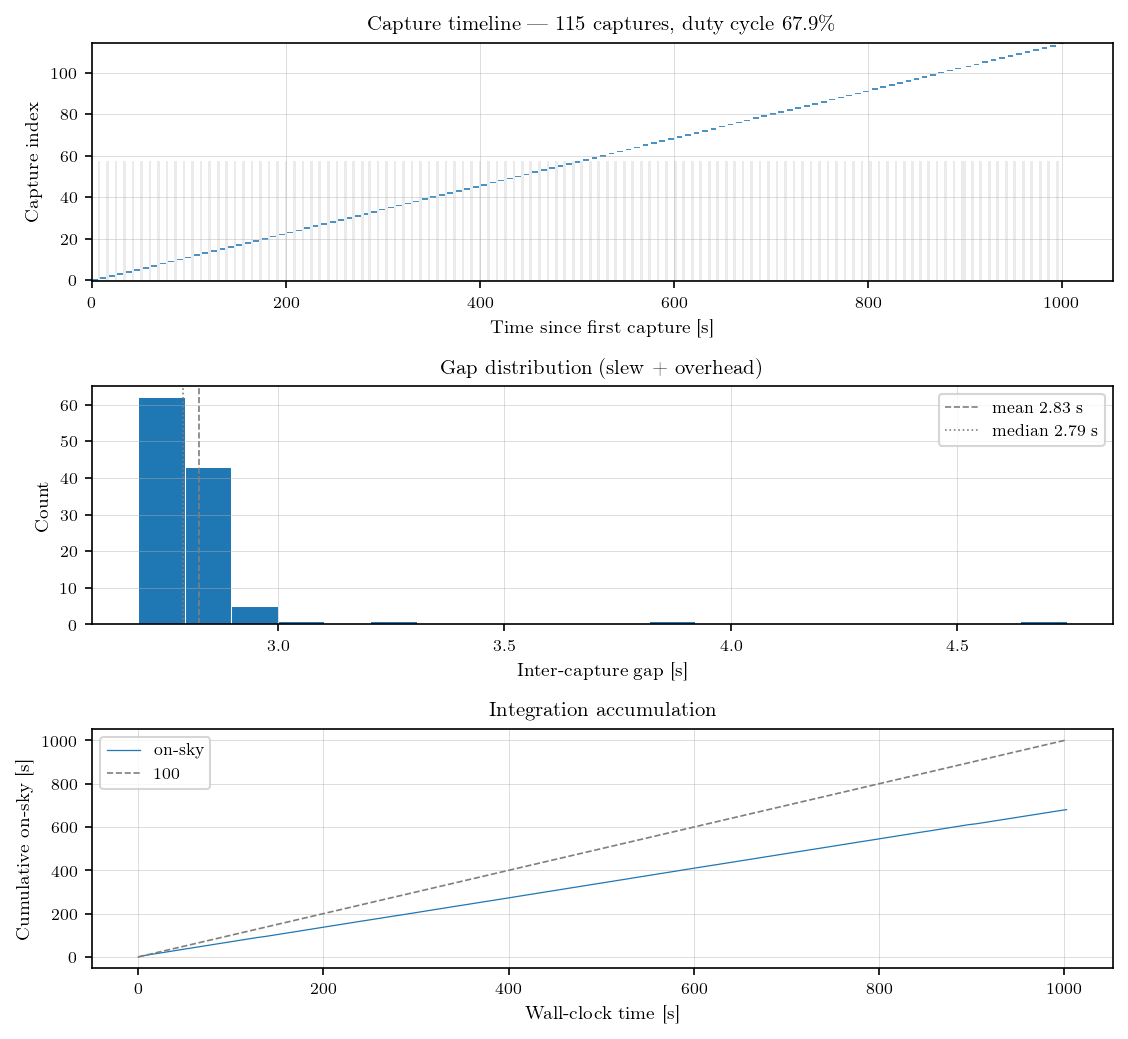

In [7]:
# ---------------------------------------------------------------------------
# Integration time coverage
# ---------------------------------------------------------------------------

t_start = np.array([float(f['unix_time_start']) for f in files_s])
t_end   = np.array([float(f['unix_time_end'])   for f in files_s])
n_acc   = np.array([int(f['n_acc'])             for f in files_s])
durs    = t_end - t_start
gaps    = t_start[1:] - t_end[:-1]
t0      = t_start[0]

total_wall = t_end[-1] - t_start[0]
total_sky  = durs.sum()
duty       = total_sky / total_wall * 100

print(f'Captures        : {len(files_s)}')
print(f'Wall-clock span : {total_wall:.1f} s  ({total_wall/60:.1f} min)')
print(f'On-sky total    : {total_sky:.1f} s  ({total_sky/60:.1f} min)')
print(f'Duty cycle      : {duty:.1f}%')
print(f'n_acc per cap   : min={n_acc.min()}  mean={n_acc.mean():.1f}  max={n_acc.max()}')
print(f'Gap (s)         : min={gaps.min():.2f}  median={np.median(gaps):.2f}  mean={gaps.mean():.2f}  max={gaps.max():.2f}')

# ── 1. Gantt timeline ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 7))

ax = axes[0]
for i, (ts, te) in enumerate(zip(t_start - t0, t_end - t0)):
    ax.barh(i, te - ts, left=ts, height=0.8, color=PRIMARY_COLOR, alpha=0.8)
# Mark gaps
for ts, te in zip(t_end[:-1] - t0, t_start[1:] - t0):
    ax.barh(0, te - ts, left=ts, height=len(files_s),
            color=NEUTRAL_COLOR, alpha=0.15, zorder=0)
ax.set_xlabel('Time since first capture [s]')
ax.set_ylabel('Capture index')
ax.set_title(rf'Capture timeline — {len(files_s)} captures, duty cycle {duty:.1f}\%')
ax.set_ylim(-0.5, len(files_s) - 0.5)

# ── 2. Gap histogram ───────────────────────────────────────────────────────
ax = axes[1]
ax.hist(gaps, bins=20, color=PRIMARY_COLOR, edgecolor='white', linewidth=0.5)
ax.axvline(gaps.mean(),   color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--',
           label=rf'mean {gaps.mean():.2f} s')
ax.axvline(np.median(gaps), color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':',
           label=rf'median {np.median(gaps):.2f} s')
ax.set_xlabel('Inter-capture gap [s]')
ax.set_ylabel('Count')
ax.set_title('Gap distribution (slew + overhead)')
ax.legend(fontsize=TICK_SIZE)

# ── 3. Cumulative integration vs wall-clock ────────────────────────────────
ax = axes[2]
t_wall = np.concatenate([[0], t_end   - t0])
t_sky  = np.concatenate([[0], np.cumsum(durs)])
ax.plot(t_wall, t_sky,   color=PRIMARY_COLOR, lw=LW_FINE, label='on-sky')
ax.plot([0, t_wall[-1]], [0, t_wall[-1]],
        color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--', label='100 % duty')
ax.set_xlabel('Wall-clock time [s]')
ax.set_ylabel('Cumulative on-sky [s]')
ax.set_title('Integration accumulation')
ax.legend(fontsize=TICK_SIZE)

fig.tight_layout()
plt.show()